In [1]:
# Ejecucion local: no se monta Google Drive.
from pathlib import Path
print(f"Directorio de trabajo: {Path.cwd()}")


Directorio de trabajo: e:\EAN\TESIS_MAESTRIA\Ciencia_de_datos\experimentos


In [2]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS NECESARIAS
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# 2. CARGAR DATASET DESDE ARCHIVO XLSX
# ============================================================
# En Google Colab puedes subir el archivo manualmente o montarlo desde Drive.
# Aquí asumimos que el archivo está en la ruta actual de trabajo.

ruta_archivo = "df_consumo_bime_clima_v3.xlsx"   # <-- Cambia este nombre por el tuyo

# Leer archivo Excel
df = pd.read_excel(ruta_archivo)

# Mostrar primeras filas para verificar carga correcta
print("Dataset cargado correctamente.")
display(df.head())

# Mostrar dimensiones iniciales
print(f"\nDimensiones iniciales del dataset: {df.shape}")

# ============================================================
# 3. DEFINIR VARIABLE OBJETIVO (TARGET)
# ============================================================

target = "consumo_promedio"

# Verificar que exista en el dataset
if target not in df.columns:
    raise ValueError(f"La variable objetivo '{target}' no existe en el dataset.")

# ============================================================
# 4. VARIABLES A ELIMINAR SEGÚN ANÁLISIS DE INGENIERÍA
# ============================================================

columnas_eliminar = [

    # --------------------------------------------------------
    # Variables con posible DATA LEAKAGE
    # (Muy relacionadas o derivadas directamente del target)
    # --------------------------------------------------------
    "metros_cubicos",
    "facturas",
    "suscriptores_facturados",
    "suscriptores_con_medidor",

    # --------------------------------------------------------
    # Variables categóricas / geográficas inicialmente removidas
    # --------------------------------------------------------
    "localidad",
    "latitud",
    "longitud",

    # --------------------------------------------------------
    # Variables climáticas redundantes / derivadas
    # --------------------------------------------------------
    "T2MWET",
    "T2MDEW",
    "T2M_RANGE",

    # --------------------------------------------------------
    # Variables de viento redundantes
    # --------------------------------------------------------
    "WS10M_MAX",
    "WS10M_MIN",
    "WS10M_RANGE",
    "WS2M_MAX",
    "WS2M_MIN",
    "WS2M_RANGE",

    # --------------------------------------------------------
    # Variables angulares inicialmente removidas
    # (Dirección del viento requiere transformación trigonométrica)
    # --------------------------------------------------------
    "WD10M",
    "WD2M",

    # --------------------------------------------------------
    # Variables radiativas redundantes
    # --------------------------------------------------------
    "ALLSKY_SFC_PAR_TOT",
    "CLRSKY_SFC_PAR_TOT",
    "ALLSKY_SFC_SW_DIFF",
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_UVA",
    "ALLSKY_SFC_UVB",
    "ALLSKY_SFC_UV_INDEX",
    "CLRSKY_SFC_SW_DWN",
    "TOA_SW_DWN"
]

# ============================================================
# 5. ELIMINAR SOLO COLUMNAS EXISTENTES (ROBUSTEZ)
# ============================================================
# Esto evita errores si alguna columna no está en el archivo.

columnas_existentes_eliminar = [
    col for col in columnas_eliminar if col in df.columns
]

df = df.drop(columns=columnas_existentes_eliminar)

# Mostrar columnas eliminadas
print("\nColumnas eliminadas:")
for col in columnas_existentes_eliminar:
    print(f" - {col}")

# ============================================================
# 6. SEPARAR FEATURES (X) Y TARGET (y)
# ============================================================

X = df.drop(columns=[target])
y = df[target]

# ============================================================
# 7. MOSTRAR RESUMEN FINAL
# ============================================================

print("\n==============================")
print("PREPROCESAMIENTO COMPLETADO")
print("==============================")

print(f"\nNúmero final de features: {X.shape[1]}")
print(f"Número de muestras: {X.shape[0]}")

print("\nFeatures finales utilizadas:")
for col in X.columns:
    print(f" - {col}")

# ============================================================
# 8. VISTA PRELIMINAR DEL DATASET LIMPIO
# ============================================================

display(X.head())

print("\nTarget preview:")
display(y.head())

Dataset cargado correctamente.


,año,localidad,BIMESTRE,metros_cubicos,facturas,consumo_promedio,suscriptores_facturados,suscriptores_con_medidor,latitud,longitud,...,WD10M,WD2M,WS10M,WS10M_MAX,WS10M_MIN,WS10M_RANGE,WS2M,WS2M_MAX,WS2M_MIN,WS2M_RANGE
0,2020,USAQUEN,1,4653292,213354,10.905097,212731.0,215097,4.73197,-74.05163,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
1,2020,CHAPINERO,1,2281601,93362,12.219109,93016.0,93684,4.67040,-74.04338,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
2,2020,SANTA FE,1,843631,33789,12.483811,33524.0,34703,4.60947,-74.08135,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
3,2020,SAN CRISTOBAL,1,1771678,80676,10.980205,80311.0,81072,4.58843,-74.07080,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
4,2020,USME,1,1570282,78240,10.035033,77876.0,79159,4.53286,-74.11451,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945



Dimensiones iniciales del dataset: (596, 49)

Columnas eliminadas:
 - metros_cubicos
 - facturas
 - suscriptores_facturados
 - suscriptores_con_medidor
 - localidad
 - latitud
 - longitud
 - T2MWET
 - T2MDEW
 - T2M_RANGE
 - WS10M_MAX
 - WS10M_MIN
 - WS10M_RANGE
 - WS2M_MAX
 - WS2M_MIN
 - WS2M_RANGE
 - WD10M
 - WD2M
 - ALLSKY_SFC_PAR_TOT
 - CLRSKY_SFC_PAR_TOT
 - ALLSKY_SFC_SW_DIFF
 - ALLSKY_SFC_SW_DNI
 - ALLSKY_SFC_UVA
 - ALLSKY_SFC_UVB
 - ALLSKY_SFC_UV_INDEX
 - CLRSKY_SFC_SW_DWN
 - TOA_SW_DWN

PREPROCESAMIENTO COMPLETADO

Número final de features: 21
Número de muestras: 596

Features finales utilizadas:
 - año
 - BIMESTRE
 - ALLSKY_SFC_LW_DWN
 - ALLSKY_SFC_SW_DWN
 - ALLSKY_SRF_ALB
 - CLOUD_AMT
 - GWETPROF
 - GWETROOT
 - GWETTOP
 - ONI
 - PRECTOTCORR
 - PRECTOTCORR_SUM
 - PS
 - QV2M
 - RH2M
 - T2M
 - T2M_MAX
 - T2M_MIN
 - TS
 - WS10M
 - WS2M


,año,BIMESTRE,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_SW_DWN,ALLSKY_SRF_ALB,CLOUD_AMT,GWETPROF,GWETROOT,GWETTOP,ONI,...,PRECTOTCORR_SUM,PS,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS10M,WS2M
0,2020,1,31.615,19.135,0.15,62.185,0.775,0.765,0.760,0.49,...,59.16,79.585,11.865,83.595,16.04,22.470,8.820,16.32,2.310,1.395
1,2020,1,31.615,19.135,0.15,62.185,0.775,0.765,0.760,0.49,...,59.16,79.585,11.865,83.595,16.04,22.470,8.820,16.32,2.310,1.395
2,2020,1,31.615,19.135,0.15,62.185,0.705,0.640,0.655,0.49,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430
3,2020,1,31.615,19.135,0.15,62.185,0.705,0.640,0.655,0.49,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430
4,2020,1,31.615,19.135,0.15,62.185,0.705,0.640,0.655,0.49,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430



Target preview:


0    10.905097
1    12.219109
2    12.483811
3    10.980205
4    10.035033
Name: consumo_promedio, dtype: float64

Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos
La columna 'año' fue convertida a formato numérico.
Se aplicó transformación log1p al target 'consumo_promedio'.

Después de quitar targets nulos:
X_model: (596, 22)
y_model: (596,)

División de datos:
Train: (417, 22), (417,)
Val:   (89, 22), (89,)
Test:  (90, 22), (90,)

PREPROCESAMIENTO PARA PYTORCH COMPLETADO

Número final de features usadas por el modelo: 22
Batch size: 32

Nombres finales de las features:
1. año
2. ALLSKY_SFC_LW_DWN
3. ALLSKY_SFC_SW_DWN
4. ALLSKY_SRF_ALB
5. CLOUD_AMT
6. GWETPROF
7. GWETROOT
8. GWETTOP
9. ONI
10. PRECTOTCORR
11. PRECTOTCORR_SUM
12. PS
13. QV2M
14. RH2M
15. T2M
16. T2M_MAX
17. T2M_MIN
18. TS
19. WS10M
20. WS2M
21. BIMESTRE_sin
22. BIMESTRE_cos

Tamaños de tensores:
X_train_tensor: torch.Size([417, 22])
y_train_tensor: torch.Size([417, 1])
X_val_tensor:   torch.Size([89, 22])
y_val_tensor:   torch.Size([89, 1])
X_test_tensor:  torch.Size([90, 22])
y_test_tensor:  torch.Size([

,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,MAE_val,RMSE_val,R2_val,MAE_test,RMSE_test,R2_test
0,400,0.05,3,3,1.0,0.8,2.433429,4.226859,0.103219,1.502615,2.071291,0.156016
1,400,0.05,4,3,0.8,0.8,2.435305,4.277962,0.081403,1.532936,2.112551,0.122057
2,400,0.05,3,3,1.0,1.0,2.447705,4.288397,0.076916,1.515804,2.079858,0.149020
3,200,0.05,3,3,1.0,0.8,2.439404,4.307663,0.068604,1.508870,2.082527,0.146835
4,200,0.05,4,3,0.8,0.8,2.442017,4.321032,0.062813,1.532135,2.117541,0.117904
5,400,0.05,4,3,0.8,1.0,2.457357,4.334808,0.056828,1.543000,2.122973,0.113373
6,200,0.05,3,3,1.0,1.0,2.456279,4.347336,0.051369,1.523015,2.094485,0.137009
7,400,0.03,3,3,1.0,0.8,2.480447,4.371421,0.040828,1.518054,2.087852,0.142466
8,200,0.05,4,3,0.8,1.0,2.459697,4.373008,0.040132,1.542799,2.125771,0.111034
9,400,0.03,4,3,0.8,1.0,2.456033,4.381358,0.036463,1.536941,2.116675,0.118626



Mejor configuración encontrada:
n_estimators: 400.000000
learning_rate: 0.050000
max_depth: 3.000000
min_child_weight: 3.000000
subsample: 1.000000
colsample_bytree: 0.800000
MAE_val: 2.433429
RMSE_val: 4.226859
R2_val: 0.103219
MAE_test: 1.502615
RMSE_test: 2.071291
R2_test: 0.156016

MEJOR MODELO XGBOOST - TRAIN
MAE  : 1.2377
RMSE : 1.8873
R²   : 0.5231

MEJOR MODELO XGBOOST - VALIDATION
MAE  : 2.4334
RMSE : 4.2269
R²   : 0.1032

MEJOR MODELO XGBOOST - TEST
MAE  : 1.5026
RMSE : 2.0713
R²   : 0.1560

Primeras 10 predicciones del mejor XGBoost:


,Valor_real,Prediccion,Error_absoluto
0,11.404461,11.223598,0.180863
1,11.192153,11.556311,0.364157
2,10.600932,11.836254,1.235322
3,15.794589,10.991443,4.803146
4,11.060142,11.676391,0.616249
5,16.104217,10.608642,5.495575
6,10.845302,11.223598,0.378297
7,14.570527,12.300551,2.269976
8,10.067235,9.997777,0.069458
9,12.082005,10.440607,1.641398



20 peores casos del mejor XGBoost:


,Valor_real,Prediccion,Error_absoluto
33,17.420833,11.586304,5.834529
89,16.849002,11.064448,5.784554
5,16.104217,10.608642,5.495575
43,17.041598,11.641746,5.399852
3,15.794589,10.991443,4.803146
88,17.271118,12.535378,4.735739
35,14.376812,10.148447,4.228365
47,13.672494,9.724872,3.947622
44,14.139062,10.440607,3.698455
73,14.275903,10.965897,3.310006



Top 20 variables más importantes del mejor XGBoost:


,feature,importance
11,PS,0.118048
9,PRECTOTCORR,0.088256
16,T2M_MIN,0.084871
20,BIMESTRE_sin,0.082640
19,WS2M,0.075123
14,T2M,0.064367
15,T2M_MAX,0.056330
8,ONI,0.051413
18,WS10M,0.050683
12,QV2M,0.047857


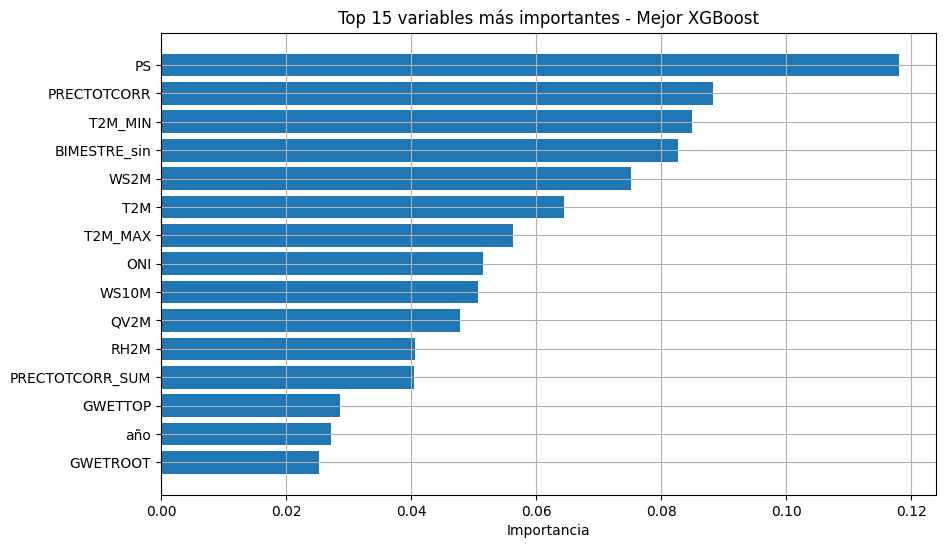

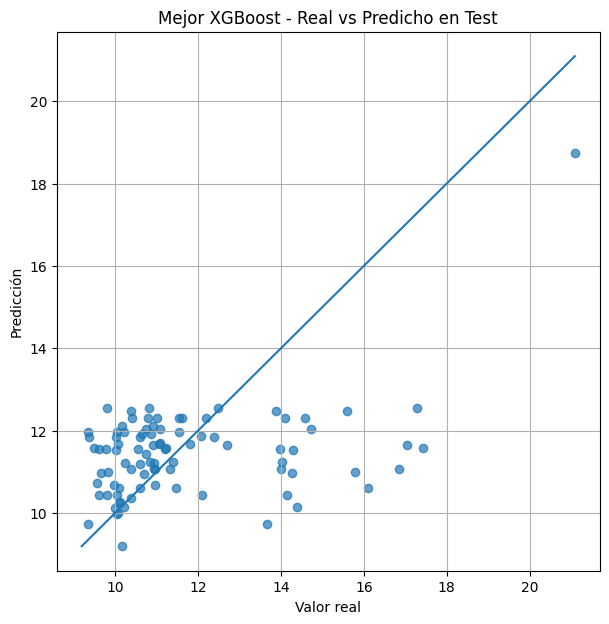


Se guardó la tabla completa de tuning en: resultados_tuning_xgboost_imputed.csv


In [4]:
# ============================================================
# 9. IMPORTAR LIBRERÍAS PARA PREPROCESAMIENTO Y PYTORCH
# ============================================================

import math
import torch
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ============================================================
# 10. HACER UNA COPIA DE SEGURIDAD DE X Y y
# ============================================================
# Esto evita modificar accidentalmente los datos originales.

X_model = X.copy()
y_model = y.copy()

# ============================================================
# 11. TRANSFORMAR BIMESTRE A REPRESENTACIÓN CÍCLICA
# ============================================================
# BIMESTRE toma valores periódicos: 1, 2, 3, 4, 5, 6
# El problema de dejarlo como entero es que:
# - 1 y 6 parecen lejanos numéricamente
# - pero realmente son cercanos en el ciclo anual
#
# Por eso usamos:
#   sin(2*pi*bimestre/6)
#   cos(2*pi*bimestre/6)

if "BIMESTRE" in X_model.columns:
    # Convertir BIMESTRE a numérico por seguridad
    X_model["BIMESTRE"] = pd.to_numeric(X_model["BIMESTRE"], errors="coerce")

    # Crear representación cíclica
    X_model["BIMESTRE_sin"] = np.sin(2 * np.pi * X_model["BIMESTRE"] / 6)
    X_model["BIMESTRE_cos"] = np.cos(2 * np.pi * X_model["BIMESTRE"] / 6)

    # Eliminar la columna original porque ya quedó representada mejor
    X_model = X_model.drop(columns=["BIMESTRE"])

    print("Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos")
else:
    print("La columna 'BIMESTRE' no está presente en X_model")

# ============================================================
# 12. ASEGURAR QUE 'año' SEA NUMÉRICO
# ============================================================
# En muchos archivos Excel algunas columnas llegan como texto.
# Aquí obligamos a que 'año' sea numérico si existe.

if "año" in X_model.columns:
    X_model["año"] = pd.to_numeric(X_model["año"], errors="coerce")
    print("La columna 'año' fue convertida a formato numérico.")
else:
    print("La columna 'año' no está presente en X_model")

# ============================================================
# 13. ASEGURAR QUE TODAS LAS FEATURES SEAN NUMÉRICAS
# ============================================================
# Como vas a entrenar una red neuronal tabular en PyTorch,
# todas las entradas deben ser numéricas.

for col in X_model.columns:
    X_model[col] = pd.to_numeric(X_model[col], errors="coerce")

# También forzamos el target a numérico
y_model = pd.to_numeric(y_model, errors="coerce")

# ============================================================
# 13.1 TRANSFORMAR EL TARGET CON log1p
# ============================================================
# Dado que consumo_promedio tiene una distribución muy sesgada
# y presenta valores extremos muy grandes, usamos log1p:
#
#   log1p(y) = log(1 + y)
#
# Esto comprime la cola larga del target y ayuda a que el modelo
# aprenda mejor la estructura general del problema.
#
# IMPORTANTE:
# Esto solo funciona si y >= 0, lo cual en este problema tiene sentido.
# Si hubiera valores negativos, habría que revisar antes.

if (y_model < 0).any():
    raise ValueError("La transformación log1p no puede aplicarse porque existen valores negativos en el target.")

y_model = np.log1p(y_model)

print("Se aplicó transformación log1p al target 'consumo_promedio'.")

# ============================================================
# 14. ELIMINAR FILAS DONDE EL TARGET SEA NULO
# ============================================================
# No se puede entrenar si la variable objetivo está vacía.

mask_target_valido = y_model.notna()

X_model = X_model.loc[mask_target_valido].reset_index(drop=True)
y_model = y_model.loc[mask_target_valido].reset_index(drop=True)

print(f"\nDespués de quitar targets nulos:")
print(f"X_model: {X_model.shape}")
print(f"y_model: {y_model.shape}")

# ============================================================
# 15. DIVIDIR EN TRAIN, VALIDATION Y TEST
# ============================================================
# Buena práctica:
# - train: para entrenar
# - validation: para ajustar hiperparámetros / early stopping
# - test: para evaluar el resultado final
#
# Aquí usamos:
# - 70% train
# - 15% validation
# - 15% test

X_train, X_temp, y_train, y_temp = train_test_split(
    X_model,
    y_model,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("\nDivisión de datos:")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

# ============================================================
# 16. IMPUTAR VALORES FALTANTES EN FEATURES
# ============================================================
# Muy importante:
# El imputador debe ajustarse SOLO con train
# y luego aplicarse a val/test.
#
# Aquí usamos la mediana porque suele ser robusta
# ante valores extremos en variables climáticas.

imputer_X = SimpleImputer(strategy="median")

X_train_imputed = imputer_X.fit_transform(X_train)
X_val_imputed   = imputer_X.transform(X_val)
X_test_imputed  = imputer_X.transform(X_test)

# ============================================================
# 17. ESCALAR FEATURES
# ============================================================
# Las redes neuronales suelen entrenar mejor cuando las variables
# tienen escalas comparables.
#
# Ajustamos el scaler SOLO con train y aplicamos a val/test.

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_imputed)
X_val_scaled   = scaler_X.transform(X_val_imputed)
X_test_scaled  = scaler_X.transform(X_test_imputed)

# ============================================================
# 18. ESCALAR EL TARGET (OPCIONAL PERO RECOMENDADO)
# ============================================================
# En regresión con deep learning, muchas veces ayuda escalar la salida.
# Esto estabiliza el entrenamiento si el target tiene magnitud grande.
#
# Luego, al evaluar, puedes revertir la escala.

scaler_y = StandardScaler()

y_train_reshaped = y_train.values.reshape(-1, 1)
y_val_reshaped   = y_val.values.reshape(-1, 1)
y_test_reshaped  = y_test.values.reshape(-1, 1)

y_train_scaled = scaler_y.fit_transform(y_train_reshaped)
y_val_scaled   = scaler_y.transform(y_val_reshaped)
y_test_scaled  = scaler_y.transform(y_test_reshaped)

# ============================================================
# 19. CONVERTIR A TENSORES DE PYTORCH
# ============================================================
# PyTorch trabaja con tensores. Para regresión usamos float32.

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_scaled, dtype=torch.float32)

# ============================================================
# 20. CREAR TensorDataset
# ============================================================
# Esto empaqueta features y target juntos.

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# ============================================================
# 21. CREAR DataLoaders
# ============================================================
# batch_size = cuántas muestras ve el modelo por iteración
# shuffle=True solo en train para mezclar ejemplos

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ============================================================
# 22. MOSTRAR RESUMEN FINAL DEL PREPROCESAMIENTO
# ============================================================

print("\n==============================")
print("PREPROCESAMIENTO PARA PYTORCH COMPLETADO")
print("==============================")

print(f"\nNúmero final de features usadas por el modelo: {X_train_tensor.shape[1]}")
print(f"Batch size: {batch_size}")

print("\nNombres finales de las features:")
columnas_finales = X_model.columns.tolist()
for i, col in enumerate(columnas_finales, start=1):
    print(f"{i}. {col}")

print("\nTamaños de tensores:")
print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"y_train_tensor: {y_train_tensor.shape}")
print(f"X_val_tensor:   {X_val_tensor.shape}")
print(f"y_val_tensor:   {y_val_tensor.shape}")
print(f"X_test_tensor:  {X_test_tensor.shape}")
print(f"y_test_tensor:  {y_test_tensor.shape}")

# ============================================================
# TUNING DE XGBOOST PARA REGRESIÓN TABULAR
# ============================================================
# Este bloque prueba múltiples combinaciones de hiperparámetros
# y compara su desempeño en validation y test.
#
# REQUISITOS:
# Deben existir previamente estas variables:
#   X_train_imputed, X_val_imputed, X_test_imputed
#   y_train, y_val, y_test
#   X_model
#
# IMPORTANTE:
# Este bloque asume que y_train, y_val, y_test están en escala log1p.
# Al final devuelve las predicciones a escala original con np.expm1().
# ============================================================

# Instalar/importar XGBoost si hace falta
try:
    from xgboost import XGBRegressor
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBRegressor

import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. FUNCIÓN AUXILIAR PARA CALCULAR MÉTRICAS
# ============================================================

def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# ============================================================
# 2. DEFINIR ESPACIO DE BÚSQUEDA
# ============================================================
# Este grid es moderado. Si tarda demasiado, luego lo reducimos.
# Si quieres una búsqueda más profunda, luego lo ampliamos.

param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Convertir el grid a lista de combinaciones
keys = list(param_grid.keys())
values = list(param_grid.values())
combinaciones = list(itertools.product(*values))

print(f"Total de combinaciones a evaluar: {len(combinaciones)}")

# ============================================================
# 3. ENTRENAR Y EVALUAR TODAS LAS COMBINACIONES
# ============================================================

resultados_tuning = []

# Convertir a arreglos numpy por seguridad
X_train_xgb = X_train_imputed
X_val_xgb   = X_val_imputed
X_test_xgb  = X_test_imputed

y_train_xgb = y_train.values
y_val_xgb   = y_val.values
y_test_xgb  = y_test.values

# Valores reales en escala original
y_val_real = np.expm1(y_val_xgb)
y_test_real = np.expm1(y_test_xgb)

for i, combo in enumerate(combinaciones, start=1):
    params = dict(zip(keys, combo))

    print("\n" + "=" * 70)
    print(f"Evaluando combinación {i}/{len(combinaciones)}")
    print(params)
    print("=" * 70)

    # Crear modelo con la combinación actual
    model = XGBRegressor(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_child_weight=params["min_child_weight"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    # Entrenar con datos imputados
    model.fit(
        X_train_xgb,
        y_train_xgb,
        eval_set=[(X_val_xgb, y_val_xgb)],
        verbose=False
    )

    # Predecir en validation y test, aún en escala log1p
    y_val_pred_log = model.predict(X_val_xgb)
    y_test_pred_log = model.predict(X_test_xgb)

    # Volver a escala original
    y_val_pred_real = np.expm1(y_val_pred_log)
    y_test_pred_real = np.expm1(y_test_pred_log)

    # Métricas
    mae_val, rmse_val, r2_val = calcular_metricas(y_val_real, y_val_pred_real)
    mae_test, rmse_test, r2_test = calcular_metricas(y_test_real, y_test_pred_real)

    # Guardar resultados
    resultados_tuning.append({
        **params,
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
        "R2_val": r2_val,
        "MAE_test": mae_test,
        "RMSE_test": rmse_test,
        "R2_test": r2_test
    })

# Convertir a DataFrame
df_resultados_tuning = pd.DataFrame(resultados_tuning)

# ============================================================
# 4. ORDENAR RESULTADOS
# ============================================================
# Ordenamos principalmente por RMSE de validation.
# También usamos MAE de validation como segundo criterio.

df_resultados_tuning = df_resultados_tuning.sort_values(
    by=["RMSE_val", "MAE_val"],
    ascending=[True, True]
).reset_index(drop=True)

print("\n" + "=" * 70)
print("TOP 10 MEJORES CONFIGURACIONES SEGÚN VALIDATION")
print("=" * 70)
display(df_resultados_tuning.head(10))

# ============================================================
# 5. TOMAR LA MEJOR CONFIGURACIÓN
# ============================================================

mejor_config = df_resultados_tuning.iloc[0].to_dict()

print("\nMejor configuración encontrada:")
for k, v in mejor_config.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

# ============================================================
# 6. REENTRENAR EL MEJOR MODELO
# ============================================================

best_xgb_model = XGBRegressor(
    n_estimators=int(mejor_config["n_estimators"]),
    learning_rate=float(mejor_config["learning_rate"]),
    max_depth=int(mejor_config["max_depth"]),
    min_child_weight=int(mejor_config["min_child_weight"]),
    subsample=float(mejor_config["subsample"]),
    colsample_bytree=float(mejor_config["colsample_bytree"]),
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

best_xgb_model.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_val_xgb, y_val_xgb)],
    verbose=False
)

# ============================================================
# 7. EVALUAR EL MEJOR MODELO
# ============================================================

y_train_pred_log = best_xgb_model.predict(X_train_xgb)
y_val_pred_log   = best_xgb_model.predict(X_val_xgb)
y_test_pred_log  = best_xgb_model.predict(X_test_xgb)

# Volver a escala original
y_train_real = np.expm1(y_train_xgb)
y_val_real   = np.expm1(y_val_xgb)
y_test_real  = np.expm1(y_test_xgb)

y_train_pred_real = np.expm1(y_train_pred_log)
y_val_pred_real   = np.expm1(y_val_pred_log)
y_test_pred_real  = np.expm1(y_test_pred_log)

mae_train, rmse_train, r2_train = calcular_metricas(y_train_real, y_train_pred_real)
mae_val, rmse_val, r2_val       = calcular_metricas(y_val_real, y_val_pred_real)
mae_test, rmse_test, r2_test    = calcular_metricas(y_test_real, y_test_pred_real)

print("\n==============================")
print("MEJOR MODELO XGBOOST - TRAIN")
print("==============================")
print(f"MAE  : {mae_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"R²   : {r2_train:.4f}")

print("\n==============================")
print("MEJOR MODELO XGBOOST - VALIDATION")
print("==============================")
print(f"MAE  : {mae_val:.4f}")
print(f"RMSE : {rmse_val:.4f}")
print(f"R²   : {r2_val:.4f}")

print("\n==============================")
print("MEJOR MODELO XGBOOST - TEST")
print("==============================")
print(f"MAE  : {mae_test:.4f}")
print(f"RMSE : {rmse_test:.4f}")
print(f"R²   : {r2_test:.4f}")

# ============================================================
# 8. MOSTRAR PREDICCIONES EN TEST
# ============================================================

resultados_best_xgb = pd.DataFrame({
    "Valor_real": y_test_real,
    "Prediccion": y_test_pred_real,
    "Error_absoluto": np.abs(y_test_real - y_test_pred_real)
})

print("\nPrimeras 10 predicciones del mejor XGBoost:")
display(resultados_best_xgb.head(10))

print("\n20 peores casos del mejor XGBoost:")
display(resultados_best_xgb.sort_values(by="Error_absoluto", ascending=False).head(20))

# ============================================================
# 9. IMPORTANCIA DE VARIABLES DEL MEJOR MODELO
# ============================================================

feature_names = X_model.columns.tolist()

importancias_best_xgb = pd.DataFrame({
    "feature": feature_names,
    "importance": best_xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 20 variables más importantes del mejor XGBoost:")
display(importancias_best_xgb.head(20))

plt.figure(figsize=(10, 6))
top_imp = importancias_best_xgb.head(15).sort_values(by="importance", ascending=True)
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importancia")
plt.title("Top 15 variables más importantes - Mejor XGBoost")
plt.grid(True)
plt.show()

# ============================================================
# 10. GRÁFICO REAL VS PREDICHO
# ============================================================

plt.figure(figsize=(7, 7))
plt.scatter(y_test_real, y_test_pred_real, alpha=0.7)

min_val = min(np.min(y_test_real), np.min(y_test_pred_real))
max_val = max(np.max(y_test_real), np.max(y_test_pred_real))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Mejor XGBoost - Real vs Predicho en Test")
plt.grid(True)
plt.show()

# ============================================================
# 11. GUARDAR RESULTADOS COMPLETOS
# ============================================================

ruta_resultados = "resultados_tuning_xgboost_imputed.csv"
df_resultados_tuning.to_csv(ruta_resultados, index=False)

print(f"\nSe guardó la tabla completa de tuning en: {ruta_resultados}")